In [6]:
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Class mapping based on your requirements
CLASS_MAP = {
    1: 'Ship',
    2: 'Noise',
    3: 'Unknown TGT',
    4: 'Coast/Port',
    5: 'My Ship',
    6: 'AIS Lost'
}

def analyze_dataset(data_dir):
    class_counts = Counter()
    anno_types = Counter()
    
    for filename in os.listdir(data_dir):
        if filename.endswith(".json"):
            with open(os.path.join(data_dir, filename), 'r') as f:
                data = json.load(f)
                
            for anno in data.get('annotations', []):
                cat_id = anno.get('category_id')
                anno_type = anno.get('type')
                
                if cat_id in CLASS_MAP:
                    class_counts[CLASS_MAP[cat_id]] += 1
                anno_types[anno_type] += 1

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Class Distribution
    sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), ax=axes[0], palette="viridis")
    axes[0].set_title('Class Distribution in W-Radar Dataset')
    axes[0].set_ylabel('Number of Annotations')
    
    # Annotation Type Distribution
    axes[1].pie(anno_types.values(), labels=anno_types.keys(), autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
    axes[1].set_title('Annotation Types (BBox vs Segmentation)')
    
    plt.tight_layout()
    plt.savefig(f'dataset_analysis_{os.path.basename(data_dir)}.png')
    plt.show()

In [7]:
dataset_folders = [
    'RealImages',
    'IMMAGINI/Cartour delta 00.30/202109150030',
    'IMMAGINI/Cartour delta 1.00/202109150100',
    'IMMAGINI/Cartour delta 1.30/202109150130'
]

Analyzing dataset: RealImages


/var/folders/1n/jsfpfzl95y17kx7vc443y7y00000gn/T/ipykernel_60941/4034546304.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), ax=axes[0], palette="viridis")


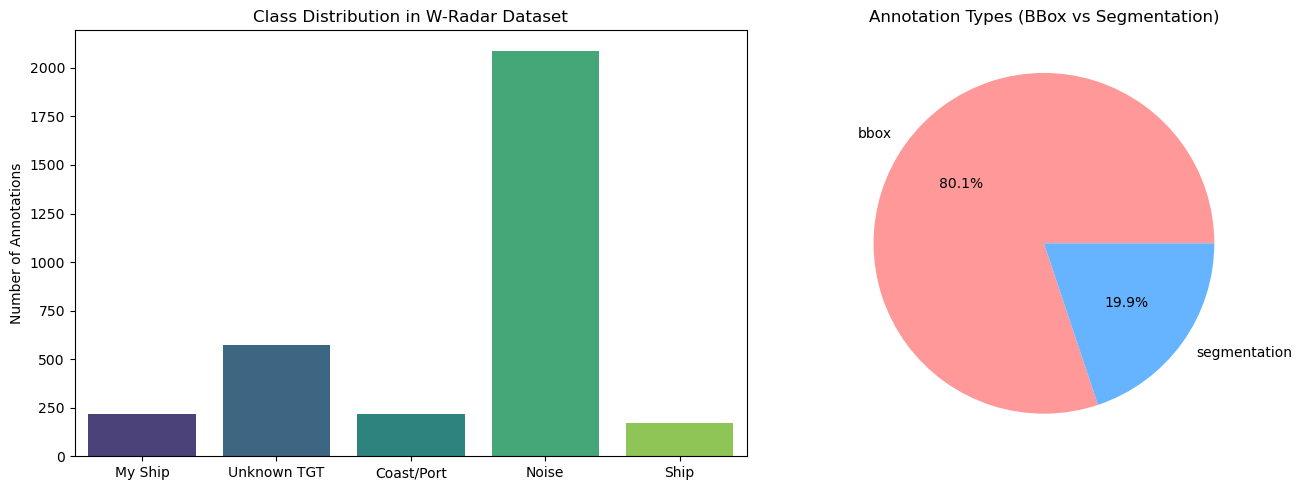

Analyzing dataset: IMMAGINI/Cartour delta 00.30/202109150030


/var/folders/1n/jsfpfzl95y17kx7vc443y7y00000gn/T/ipykernel_60941/4034546304.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), ax=axes[0], palette="viridis")


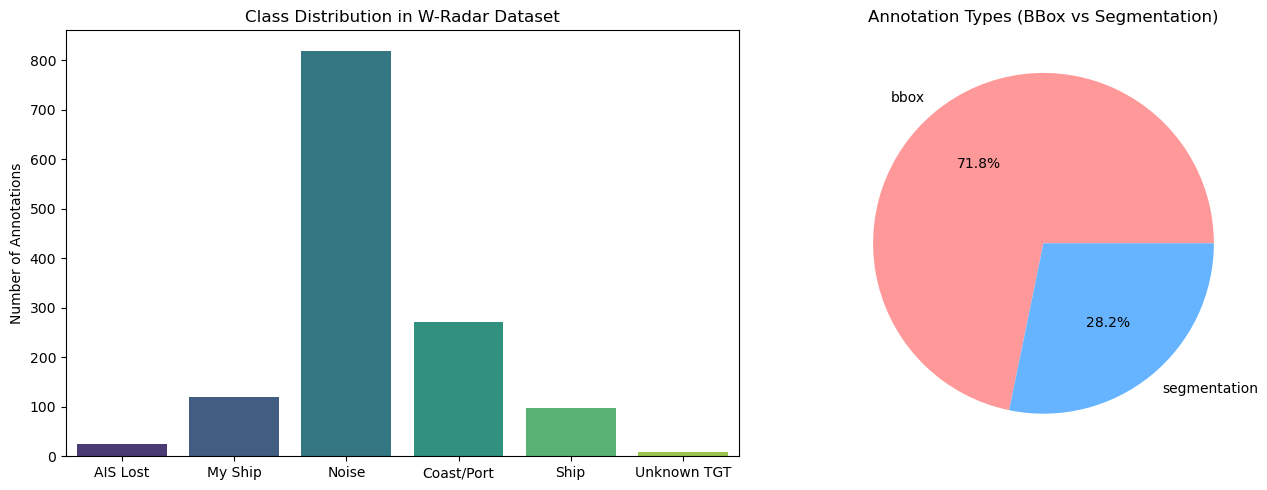

Analyzing dataset: IMMAGINI/Cartour delta 1.00/202109150100


/var/folders/1n/jsfpfzl95y17kx7vc443y7y00000gn/T/ipykernel_60941/4034546304.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), ax=axes[0], palette="viridis")


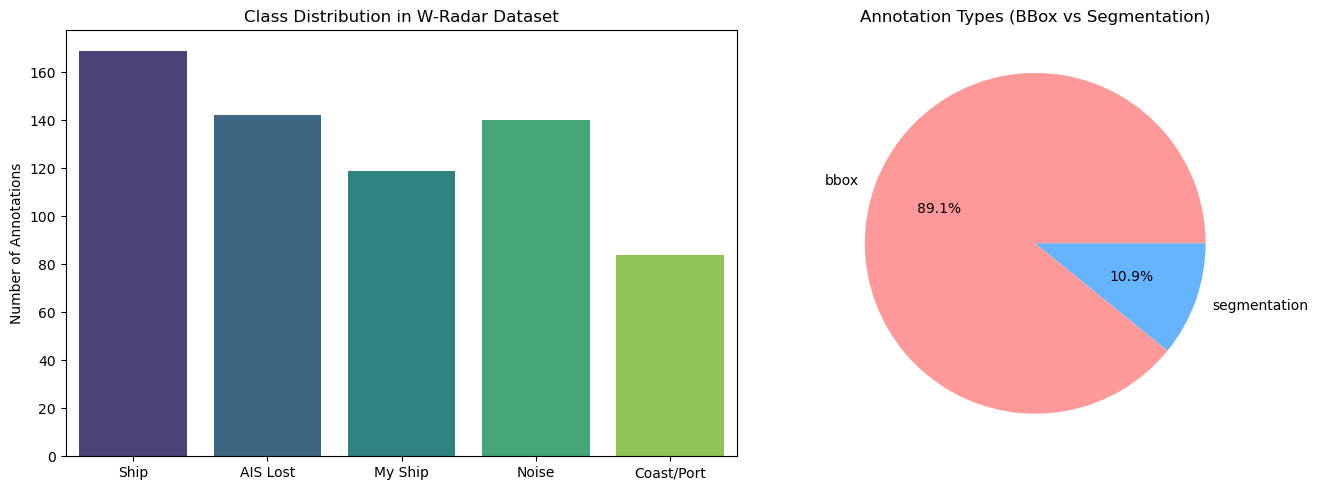

Analyzing dataset: IMMAGINI/Cartour delta 1.30/202109150130


/var/folders/1n/jsfpfzl95y17kx7vc443y7y00000gn/T/ipykernel_60941/4034546304.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), ax=axes[0], palette="viridis")


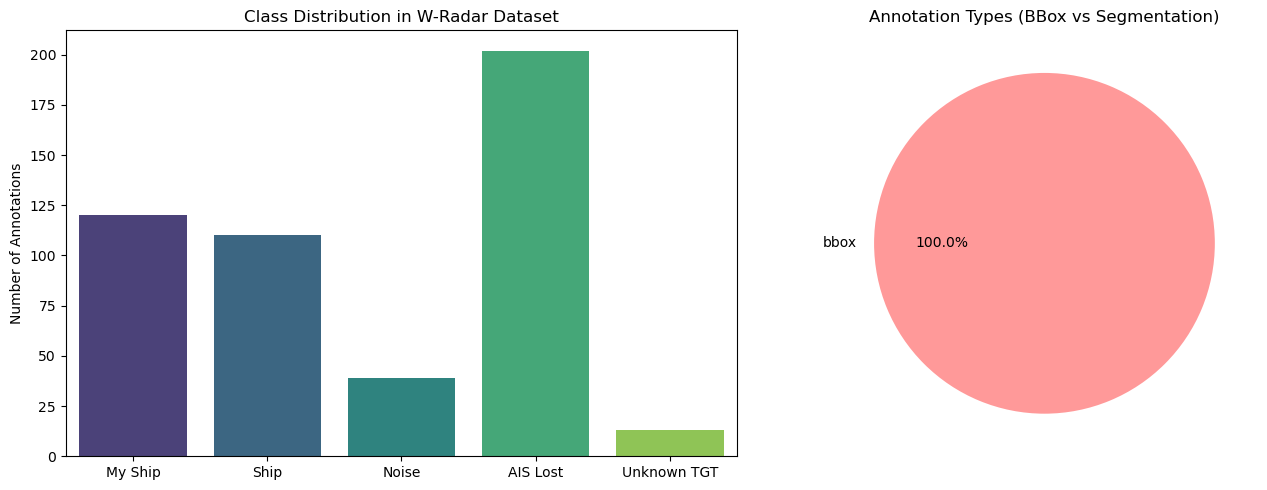

In [8]:
for folder in dataset_folders:
    print(f"Analyzing dataset: {folder}")
    analyze_dataset(folder)

In [ ]:
analyze_dataset('IMMAGINI/Cartour delta 00.30/202109150030')

In [ ]:
import os
import json
import glob
from sklearn.model_selection import train_test_split, KFold

def merge_and_split_datasets(dataset_folders, output_dir, test_size=0.2, n_splits=5):
    os.makedirs(output_dir, exist_ok=True)
    all_files = []
    
    # 1. Gather ALL files across ALL folders
    for folder in dataset_folders:
        json_files = glob.glob(os.path.join(folder, '*.json'))
        for jf in json_files:
            # We store the full relative path without extension (e.g., "RealImages/R_311782")
            base_path = os.path.splitext(jf)[0]
            all_files.append(base_path)
            
    # 2. Hold-out Test Set Split
    trainval_files, test_files = train_test_split(all_files, test_size=test_size, random_state=42)
    
    splits = {
        "test": test_files,
        "folds": {}
    }
    
    # 3. 5-Fold Cross Validation on the TrainVal portion
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(trainval_files)):
        splits["folds"][f"fold_{fold+1}"] = {
            "train": [trainval_files[i] for i in train_idx],
            "val": [trainval_files[i] for i in val_idx]
        }
        
    out_path = os.path.join(output_dir, 'merged_dataset_splits.json')
    with open(out_path, 'w') as f:
        json.dump(splits, f, indent=4)
        
    print(f"Merge & Split complete! Saved to {out_path}")
    print(f"Total Images: {len(all_files)} | TrainVal: {len(trainval_files)} | Test: {len(test_files)}")

# Execute it once:
dataset_folders = [
    'RealImages',
    'IMMAGINI/Cartour delta 00.30/202109150030',
    'IMMAGINI/Cartour delta 1.00/202109150100',
    'IMMAGINI/Cartour delta 1.30/202109150130'
]
merge_and_split_datasets(dataset_folders, 'MasterSplits')

In [ ]:
import os
import json
import torch
import cv2
import numpy as np
from datetime import datetime
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import Mask2FormerForUniversalSegmentation, Mask2FormerImageProcessor
from torch.amp import autocast, GradScaler

class WRadarDataset(Dataset):
    def __init__(self, file_list, processor):
        # We drop 'data_dir' since file_list now contains full paths (e.g., "RealImages/R_123")
        self.file_list = file_list
        self.processor = processor
        
    def __len__(self):
        return len(self.file_list)
    
    def __getitem__(self, idx):
        base_path = self.file_list[idx]
        img_path = f"{base_path}.png"
        json_path = f"{base_path}.json"
        
        # 1. Load Image & Convert to Grayscale
        image = cv2.imread(img_path)
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        
        # Mask2Former (and SAM2) requires 3 color channels. 
        # We convert back to RGB, keeping it 3-channel but entirely stripping color information!
        image = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
        
        h, w, _ = image.shape
        
        with open(json_path, 'r') as f:
            anno_data = json.load(f)
            
        instance_seg = np.zeros((h, w), dtype=np.int32)
        instance_id_to_semantic_id = {}
        
        for i, ann in enumerate(anno_data.get('annotations', [])):
            instance_id = i + 1 
            cat_id = ann['category_id']
            instance_id_to_semantic_id[instance_id] = cat_id
            
            if ann['type'] == 'bbox':
                xmin, ymin = int(ann['xmin']), int(ann['ymin'])
                xmax, ymax = xmin + int(ann['width']), ymin + int(ann['height'])
                instance_seg[ymin:ymax, xmin:xmax] = instance_id
            elif ann['type'] == 'segmentation':
                poly = np.array(ann['segmentation'][0], dtype=np.int32).reshape((-1, 2))
                cv2.fillPoly(instance_seg, [poly], instance_id)
                
        # 2. Dynamic Resolution Handling (Radar is always square and on the left)
        # We crop the width to exactly match the image's own height!
        crop_size = h 
        if w > crop_size:
            image = image[:, :crop_size, :]
            instance_seg = instance_seg[:, :crop_size]
            
            # Clean up instances that were completely cropped out to avoid target errors
            active_instances = np.unique(instance_seg)
            instance_id_to_semantic_id = {
                inst_id: sem_id 
                for inst_id, sem_id in instance_id_to_semantic_id.items() 
                if inst_id in active_instances
            }
                
        # Process for Mask2Former
        inputs = self.processor(
            images=image, 
            segmentation_maps=instance_seg, 
            instance_id_to_semantic_id=instance_id_to_semantic_id,
            return_tensors="pt"
        )
        
        processed_inputs = {}
        for k, v in inputs.items():
            if isinstance(v, list):
                processed_inputs[k] = v[0]  
            elif isinstance(v, torch.Tensor):
                processed_inputs[k] = v.squeeze(0) 
            else:
                processed_inputs[k] = v
                
        return processed_inputs

def compute_fast_batch_iou(outputs, mask_labels):
    """Calculates a fast binary IoU (Foreground vs Background)"""
    with torch.no_grad():
        pred_masks = outputs.masks_queries_logits > 0 
        total_iou = 0.0
        
        for i in range(len(mask_labels)):
            if len(mask_labels[i]) == 0:
                continue # Skip if no ground truth in this image
                
            true_fg = (mask_labels[i].sum(dim=0) > 0).float()
            pred_resized = torch.nn.functional.interpolate(
                pred_masks[i].unsqueeze(0).float(), 
                size=true_fg.shape[-2:], 
                mode="bilinear", 
                align_corners=False
            ).squeeze(0)
            
            pred_fg = (pred_resized.sum(dim=0) > 0).float()
            
            intersection = (pred_fg * true_fg).sum()
            union = pred_fg.sum() + true_fg.sum() - intersection
            
            iou = (intersection / (union + 1e-6)).item()
            total_iou += iou
            
        return total_iou / len(mask_labels) if len(mask_labels) > 0 else 0.0

def train_vit_segmentation(
    data_dir, 
    split_json_path, 
    fold, 
    batch_size, 
    learning_rate, 
    epochs, 
    model_checkpoint,
    crop_width
):
    with open(split_json_path, 'r') as f:
        splits = json.load(f)
        
    train_files = splits["folds"][fold]["train"]
    val_files = splits["folds"][fold]["val"] # Load validation set
    
    #processor = Mask2FormerImageProcessor(ignore_index=0, reduce_labels=False)
    processor = Mask2FormerImageProcessor(ignore_index=0, size={"height": 512, "width": 512})
    model = Mask2FormerForUniversalSegmentation.from_pretrained(model_checkpoint)
    
    # Initialize Datasets with the Crop Width
    train_dataset = WRadarDataset(data_dir, train_files, processor, crop_width=crop_width)
    val_dataset = WRadarDataset(data_dir, val_files, processor, crop_width=crop_width)
    
    def collate_fn(batch):
        pixel_values = torch.stack([item["pixel_values"] for item in batch])
        pixel_mask = torch.stack([item["pixel_mask"] for item in batch]) if "pixel_mask" in batch[0] else None
        class_labels = [item["class_labels"] for item in batch]
        mask_labels = [item["mask_labels"] for item in batch]
        return {
            "pixel_values": pixel_values,
            "pixel_mask": pixel_mask,
            "class_labels": class_labels,
            "mask_labels": mask_labels
        }

    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    
    # Ensure we are using CUDA
    device = torch.device("cuda")
    model.to(device)
    
    # Initialize the AMP Scaler
    scaler = GradScaler('cuda')
    
    print(f"Starting training on device: {device} with AMP Enabled")
    print(f"Train Size: {len(train_dataset)} | Val Size: {len(val_dataset)} | Fold: {fold}")
    
    best_val_iou = 0.0
    session_date = datetime.now().strftime("%Y%m%d_%H%M%S")
    best_model_filename = f"vit_wradar_{fold}_best_{session_date}.pth"
    
    for epoch in range(epochs):
        # ==========================================
        # TRAINING PHASE
        # ==========================================
        model.train()
        running_loss = 0.0
        running_iou = 0.0
        
        with tqdm(total=len(train_dataset), desc=f"Epoch {epoch+1}/{epochs} [Train]", unit="img") as pbar:
            for step, batch in enumerate(train_dataloader, 1):
                optimizer.zero_grad()
                
                current_batch_size = len(batch["pixel_values"])
                pixel_values = batch["pixel_values"].to(device)
                pixel_mask = batch["pixel_mask"].to(device) if batch["pixel_mask"] is not None else None
                
                device_class_labels = [l.to(device) for l in batch["class_labels"]]
                device_mask_labels = [m.to(device) for m in batch["mask_labels"]]
                
                # --- Run the forward pass in Mixed Precision ---
                with autocast('cuda'):
                    outputs = model(
                        pixel_values=pixel_values, 
                        pixel_mask=pixel_mask,
                        class_labels=device_class_labels,
                        mask_labels=device_mask_labels
                    )
                    loss = outputs.loss
                
                # NaN Loss Check (Forward Pass)
                if torch.isnan(loss) or torch.isinf(loss):
                    print(f"\n[Warning] NaN loss at step {step}. Skipping.")
                    optimizer.zero_grad()
                    pbar.update(current_batch_size)
                    continue
                
                # --- Scale the loss and run backward pass ---
                scaler.scale(loss).backward()
                
                # Unscale the gradients so we can inspect/clip them
                scaler.unscale_(optimizer)
                
                # NaN Gradient Check (Backward Pass)
                has_corrupted_grad = False
                for param in model.parameters():
                    if param.grad is not None and not torch.isfinite(param.grad).all():
                        has_corrupted_grad = True
                        break
                        
                if has_corrupted_grad:
                    print(f"\n[Warning] Corrupted gradients at step {step}. Scaler will auto-adjust.")
                    # Notice we DO NOT use `continue` here! 
                    # We just skip clipping so we don't do math on Infinity/NaN.
                else:
                    # Clip gradients safely
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.01)

                # Step the optimizer and update the scaler
                # If grads contained NaN, scaler.step() automatically skips the optimizer update.
                scaler.step(optimizer)
                
                # scaler.update() resets the unscale state. 
                # If it saw NaNs, it dramatically lowers the scale factor for the next batch!
                scaler.update()
                
                # ... proceed to metric calculation ...
                batch_iou = compute_fast_batch_iou(outputs, device_mask_labels)
                running_loss += loss.item()
                running_iou += batch_iou
                
                pbar.update(current_batch_size)
                pbar.set_postfix({
                    "Avg Loss": f"{running_loss/step:.4f}", 
                    "Avg IoU": f"{running_iou/step:.4f}"
                })
                
        # ==========================================
        # VALIDATION PHASE
        # ==========================================
        model.eval()
        val_running_iou = 0.0
        
        with torch.no_grad():
            with tqdm(total=len(val_dataset), desc=f"Epoch {epoch+1}/{epochs} [Val]  ", unit="img") as pbar:
                for step, batch in enumerate(val_dataloader, 1):
                    current_batch_size = len(batch["pixel_values"])
                    pixel_values = batch["pixel_values"].to(device)
                    device_mask_labels = [m.to(device) for m in batch["mask_labels"]]
                    
                    outputs = model(pixel_values=pixel_values)
                    
                    batch_iou = compute_fast_batch_iou(outputs, device_mask_labels)
                    val_running_iou += batch_iou
                    
                    pbar.update(current_batch_size)
                    pbar.set_postfix({"Avg IoU": f"{val_running_iou/step:.4f}"})
                    
        epoch_val_iou = val_running_iou / len(val_dataloader)
        
        # ==========================================
        # SAVE BEST MODEL CHECK
        # ==========================================
        if epoch_val_iou > best_val_iou:
            print(f"--> Validation IoU improved from {best_val_iou:.4f} to {epoch_val_iou:.4f}! Saving model...")
            best_val_iou = epoch_val_iou
            torch.save(model.state_dict(), best_model_filename)
        else:
            print(f"--> Validation IoU did not improve. (Best: {best_val_iou:.4f})")
            
        print("-" * 50)

    print(f"Training Complete! Best model saved as: {best_model_filename} with Val IoU: {best_val_iou:.4f}")

In [ ]:
def calculate_segmentation_metrics(pred_mask, gt_mask, num_classes=6):
    """
    Computes Intersection over Union (IoU), Precision, Recall, and F1 for each class.
    Args:
        pred_mask (np.ndarray): 2D array of predicted class IDs.
        gt_mask (np.ndarray): 2D array of ground truth class IDs.
        num_classes (int): Total number of semantic classes.
    """
    metrics = {}
    for class_id in range(1, num_classes + 1):
        pred_c = (pred_mask == class_id)
        gt_c = (gt_mask == class_id)
        
        tp = np.sum(pred_c & gt_c)
        fp = np.sum(pred_c & ~gt_c)
        fn = np.sum(~pred_c & gt_c)
        
        iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        
        metrics[CLASS_MAP.get(class_id, f"Class {class_id}")] = {
            'IoU': round(iou, 4),
            'Precision': round(precision, 4),
            'Recall': round(recall, 4),
            'F1_Score': round(f1, 4),
            'Support_Pixels': int(np.sum(gt_c))
        }
        
    return metrics

# Example usage inside your inference loop:
# batch_metrics = calculate_segmentation_metrics(predicted_mask.numpy(), true_mask.numpy(), num_classes=6)

In [2]:
DATA_DIR = 'RealImages'
SPLIT_JSON_PATH = 'RealImages/output_splits/dataset_splits.json'
FOLD = "fold_1"

BATCH_SIZE = 1
LEARNING_RATE = 1e-5
EPOCHS = 20
#MODEL_CHECKPOINT = "facebook/mask2former-swin-tiny-coco-instance"
MODEL_CHECKPOINT = "facebook/mask2former-swin-base-coco-instance"
CROP_WIDTH = 1024

train_vit_segmentation(
    data_dir=DATA_DIR, 
    split_json_path=SPLIT_JSON_PATH, 
    fold=FOLD, 
    batch_size=BATCH_SIZE, 
    learning_rate=LEARNING_RATE, 
    epochs=EPOCHS, 
    model_checkpoint=MODEL_CHECKPOINT,
    crop_width=CROP_WIDTH
)

Loading weights:   0%|          | 0/782 [00:00<?, ?it/s]

Starting training on device: cuda with AMP Enabled
Train Size: 68 | Val Size: 18 | Fold: fold_1


Epoch 1/20 [Train]:   1%|▏         | 1/68 [00:01<01:24,  1.26s/img, Avg Loss=103.4768, Avg IoU=0.0016]


[Warning] Corrupted gradients at step 1. Scaler will auto-adjust.


Epoch 1/20 [Train]:   3%|▎         | 2/68 [00:01<00:45,  1.44img/s, Avg Loss=107.8841, Avg IoU=0.0034]

...

--> Validation IoU did not improve. (Best: 0.4834)
--------------------------------------------------


Epoch 19/20 [Val]  : 100%|██████████| 18/18 [00:08<00:00,  2.08img/s, Avg IoU=0.3968]


--> Validation IoU did not improve. (Best: 0.4834)
--------------------------------------------------


Epoch 20/20 [Val]  : 100%|██████████| 18/18 [00:08<00:00,  2.14img/s, Avg IoU=0.4959]


--> Validation IoU improved from 0.4834 to 0.4959! Saving model...
--------------------------------------------------
Training Complete! Best model saved as: vit_wradar_fold_1_best_20260414_165129.pth with Val IoU: 0.4959


In [5]:
import os
import json
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches # <--- NEW IMPORT FOR LEGEND
from tqdm import tqdm
from transformers import Mask2FormerForUniversalSegmentation, Mask2FormerImageProcessor

# ==========================================
# INFERENCE CONFIGURATION
# ==========================================
DATA_DIR = 'RealImages'
SPLIT_JSON_PATH = 'RealImages/output_splits/dataset_splits.json'
MODEL_CHECKPOINT = "facebook/mask2former-swin-base-coco-instance"

# UPDATE THIS to your actual saved best model filename!
BEST_MODEL_WEIGHTS = "vit_wradar_fold_1_best_20260414_165129.pth" 
CROP_WIDTH = 1024
OUTPUT_VIS_DIR = "RealImages/inference_results"

# Map to translate category IDs to human-readable names
CLASS_MAP = {
    1: 'Ship',
    2: 'Noise',
    3: 'Unknown TGT',
    4: 'Coast/Port',
    5: 'My Ship'
}
# ==========================================

def run_inference_and_evaluate():
    os.makedirs(OUTPUT_VIS_DIR, exist_ok=True)
    
    with open(SPLIT_JSON_PATH, 'r') as f:
        splits = json.load(f)
    test_files = splits["test"]
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Running inference on device: {device}")
    
    processor = Mask2FormerImageProcessor(ignore_index=0, size={"height": 512, "width": 512})
    model = Mask2FormerForUniversalSegmentation.from_pretrained(MODEL_CHECKPOINT)
    model.load_state_dict(torch.load(BEST_MODEL_WEIGHTS, map_location=device))
    model.to(device)
    model.eval()
    
    class_metrics = {cat_id: {'intersection': 0, 'union': 0} for cat_id in CLASS_MAP.keys()}
    total_iou = 0.0
    
    with torch.no_grad():
        for base_name in tqdm(test_files, desc="Evaluating Test Set"):
            img_path = os.path.join(DATA_DIR, f"{base_name}.png")
            json_path = os.path.join(DATA_DIR, f"{base_name}.json")
            
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            if CROP_WIDTH and image.shape[1] > CROP_WIDTH:
                image = image[:, :CROP_WIDTH, :]
                
            original_h, original_w, _ = image.shape
            
            # --- Load Ground Truth ---
            with open(json_path, 'r') as f:
                anno_data = json.load(f)
                
            true_semantic_mask = np.zeros((original_h, original_w), dtype=np.uint8)
            for ann in anno_data.get('annotations', []):
                cat_id = ann['category_id']
                if ann['type'] == 'bbox':
                    xmin, ymin = int(ann['xmin']), int(ann['ymin'])
                    xmax, ymax = xmin + int(ann['width']), ymin + int(ann['height'])
                    true_semantic_mask[ymin:ymax, xmin:xmax] = cat_id
                elif ann['type'] == 'segmentation':
                    poly = np.array(ann['segmentation'][0], dtype=np.int32).reshape((-1, 2))
                    cv2.fillPoly(true_semantic_mask, [poly], cat_id)
            
            if CROP_WIDTH and true_semantic_mask.shape[1] > CROP_WIDTH:
                true_semantic_mask = true_semantic_mask[:, :CROP_WIDTH]
                
            # --- Forward Pass ---
            inputs = processor(images=image, return_tensors="pt")
            pixel_values = inputs["pixel_values"].to(device)
            outputs = model(pixel_values=pixel_values)
            
            # --- Post-Process Predictions ---
            pred_maps = processor.post_process_instance_segmentation(
                outputs, 
                target_sizes=[(original_h, original_w)]
            )[0]
            
            pred_instance_mask = pred_maps['segmentation'].cpu().numpy()
            segments_info = pred_maps['segments_info']
            
            pred_semantic_mask = np.zeros((original_h, original_w), dtype=np.uint8)
            for seg in segments_info:
                inst_id = seg['id']
                cat_id = seg['label_id']
                pred_semantic_mask[pred_instance_mask == inst_id] = cat_id
            
            # --- Calculate Per-Class IoU ---
            for cat_id in CLASS_MAP.keys():
                true_class_mask = (true_semantic_mask == cat_id)
                pred_class_mask = (pred_semantic_mask == cat_id)
                
                intersection = np.logical_and(true_class_mask, pred_class_mask).sum()
                union = np.logical_or(true_class_mask, pred_class_mask).sum()
                
                if union > 0:
                    class_metrics[cat_id]['intersection'] += intersection
                    class_metrics[cat_id]['union'] += union
            
            true_fg = (true_semantic_mask > 0)
            pred_fg = (pred_semantic_mask > 0)
            img_intersection = np.logical_and(true_fg, pred_fg).sum()
            img_union = np.logical_or(true_fg, pred_fg).sum()
            total_iou += img_intersection / (img_union + 1e-6)
            
            # ==========================================
            # VISUALIZATION & LEGEND CREATION
            # ==========================================
            # Slightly increased figsize width to accommodate the legend
            fig, axes = plt.subplots(1, 3, figsize=(20, 6))
            
            axes[0].imshow(image)
            axes[0].set_title(f"Original Radar: {base_name}")
            axes[0].axis('off')
            
            axes[1].imshow(image)
            axes[1].imshow(np.ma.masked_where(true_semantic_mask == 0, true_semantic_mask), cmap='nipy_spectral', vmin=1, vmax=5, alpha=0.6)
            axes[1].set_title("Ground Truth Classes")
            axes[1].axis('off')
            
            axes[2].imshow(image)
            axes[2].imshow(np.ma.masked_where(pred_semantic_mask == 0, pred_semantic_mask), cmap='nipy_spectral', vmin=1, vmax=5, alpha=0.6)
            axes[2].set_title(f"Model Prediction")
            axes[2].axis('off')
            
            # --- Build the Legend ---
            cmap = plt.get_cmap('nipy_spectral')
            norm = plt.Normalize(vmin=1, vmax=5)
            
            legend_patches = []
            for cat_id, name in CLASS_MAP.items():
                # Extract the exact color used by the plot for this category
                color = cmap(norm(cat_id))
                legend_patches.append(mpatches.Patch(color=color, label=name, alpha=0.6))
                
            # Place the legend on the 3rd plot, pushed slightly outside the image frame
            axes[2].legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(1.05, 1), title="Classes", borderaxespad=0.)
            
            plt.tight_layout()
            vis_path = os.path.join(OUTPUT_VIS_DIR, f"{base_name}_inference.png")
            # bbox_inches='tight' ensures the legend doesn't get chopped off when saving!
            plt.savefig(vis_path, bbox_inches='tight') 
            plt.close()

    # --- Final Output Formatting ---
    final_test_iou = total_iou / len(test_files)
    
    print("\n" + "="*50)
    print("TEST SET EVALUATION COMPLETE")
    print("="*50)
    print(f"Overall Test Set Foreground mIoU: {final_test_iou:.4f}\n")
    
    print("--- PER-CLASS IoU ---")
    mean_class_iou_accumulator = []
    
    for cat_id, name in CLASS_MAP.items():
        inter = class_metrics[cat_id]['intersection']
        uni = class_metrics[cat_id]['union']
        
        if uni > 0:
            cls_iou = inter / uni
            mean_class_iou_accumulator.append(cls_iou)
            print(f"{name:<15}: {cls_iou:.4f}")
        else:
            print(f"{name:<15}: N/A (Not present in test set)")
            
    if mean_class_iou_accumulator:
        print(f"\nMean Class IoU (mIoU): {sum(mean_class_iou_accumulator) / len(mean_class_iou_accumulator):.4f}")
    print("="*50)
    print(f"Visualizations saved to: {OUTPUT_VIS_DIR}")

In [6]:
run_inference_and_evaluate()

Running inference on device: cuda


Loading weights:   0%|          | 0/782 [00:00<?, ?it/s]

Evaluating Test Set: 100%|██████████| 22/22 [00:19<00:00,  1.12it/s]


TEST SET EVALUATION COMPLETE
Overall Test Set Foreground mIoU: 0.7238

--- PER-CLASS IoU ---
Ship           : 0.4471
Noise          : 0.0000
Unknown TGT    : 0.5559
Coast/Port     : 0.8707
My Ship        : 0.7017

Mean Class IoU (mIoU): 0.5151
Visualizations saved to: RealImages/inference_results
